# **Airbnb Price Prediction Using Supervised Machine Learning**

In [3]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
df = pd.read_csv('Cleaned_Data.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 99342
Columns: 20


In [4]:
print("Column Names:")
print(df.columns.tolist())


Column Names:
['Unnamed: 0', 'index', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews']


In [5]:
df.head()

,Unnamed: 0,index,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews
0,0,0,Clean & quiet apt home by the park,80014485718,UNCONFIRMED,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,0,strict,Private room,2020.0,966,$193,10.0,9.0
1,1,1,Skylit Midtown Castle,52335172823,VERIFIED,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,0,moderate,Entire home/apt,2007.0,142,$28,30.0,45.0
2,2,4,Entire Apt: Spacious Studio/Loft by central park,92037596077,VERIFIED,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,0,moderate,Entire home/apt,2009.0,204,$41,10.0,9.0
3,3,5,Large Cozy 1 BR Apartment In Midtown East,45498551794,VERIFIED,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,1,flexible,Entire home/apt,2013.0,577,$115,3.0,74.0
4,4,7,BlissArtsSpace!,90821839709,UNCONFIRMED,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,0,moderate,Private room,2009.0,1060,$212,45.0,49.0


In [6]:
# Check the target variable

print("Target variable: price")
print("Data type:", df['price'].dtype)
print("Missing values:", df['price'].isnull().sum())
print("Minimum price:", df['price'].min())
print("Maximum price:", df['price'].max())
print("Average price:", df['price'].mean())
print("Median price:", df['price'].median())

Target variable: price
Data type: int64
Missing values: 0
Minimum price: 50
Maximum price: 1200
Average price: 625.484387268225
Median price: 624.0


In [7]:
df['price'].describe()

,price
count,99342.000000
mean,625.484387
std,331.739485
min,50.000000
25%,340.000000
50%,624.000000
75%,913.000000
max,1200.000000


In [10]:
print("All columns:")
for i, col in enumerate(df.columns, start=1):
    print(i, "→", col)

print("\nData types:")
print(df.dtypes)

All columns:
1 → Unnamed: 0
2 → index
3 → NAME
4 → host id
5 → host_identity_verified
6 → host name
7 → neighbourhood group
8 → neighbourhood
9 → lat
10 → long
11 → country
12 → country code
13 → instant_bookable
14 → cancellation_policy
15 → room type
16 → Construction year
17 → price
18 → service fee
19 → minimum nights
20 → number of reviews

Data types:
Unnamed: 0                  int64
index                       int64
NAME                       object
host id                     int64
host_identity_verified     object
host name                  object
neighbourhood group        object
neighbourhood              object
lat                       float64
long                      float64
country                    object
country code               object
instant_bookable            int64
cancellation_policy        object
room type                  object
Construction year         float64
price                       int64
service fee                object
minimum nights            fl

In [11]:
# Step 4: Feature Selection

# Define the target variable
y = df['price']

# Select useful features
features = [
    'host_identity_verified',
    'neighbourhood group',
    'neighbourhood',
    'lat',
    'long',
    'instant_bookable',
    'cancellation_policy',
    'room type',
    'Construction year',
    'minimum nights',
    'number of reviews'
]

X = df[features]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

print("\nFeature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Features selected:
['host_identity_verified', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'minimum nights', 'number of reviews']

Target variable:
price

Feature dataset shape: (99342, 11)
Target dataset shape: (99342,)


In [12]:
# Step 5A: Identify categorical and numerical features

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['host_identity_verified', 'neighbourhood group', 'neighbourhood', 'cancellation_policy', 'room type']

Numerical features:
['lat', 'long', 'instant_bookable', 'Construction year', 'minimum nights', 'number of reviews']


In [14]:
# Define target variable
target = 'price'

# Define features
features = [
    'host_identity_verified',
    'neighbourhood group',
    'neighbourhood',
    'lat',
    'long',
    'instant_bookable',
    'cancellation_policy',
    'room type',
    'Construction year',
    'minimum nights',
    'number of reviews'
]

# Separate features and target
X = df[features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (79473, 11)
Testing feature shape: (19869, 11)
Training target shape: (79473,)
Testing target shape: (19869,)


In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Numerical feature preprocessing
numerical_transformer = StandardScaler()

# Categorical feature preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [16]:
# Fit the preprocessor only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (79473, 245)
Processed testing data shape: (19869, 245)


In [17]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [18]:
# Make predictions on the test dataset
y_pred_linear = linear_model.predict(X_test_processed)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred_linear[:10])

Predictions generated successfully!
First 10 predictions:
[614.93838677 600.78658944 617.86855198 624.9447677  622.15441245
 624.15137517 670.10383654 618.10448373 801.95028973 635.05341221]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Evaluation")
print("--------------------------------")
print("MAE :", round(mae_linear, 2))
print("MSE :", round(mse_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Evaluation
--------------------------------
MAE : 286.93
MSE : 110293.2
RMSE: 332.1
R²  : -0.0021


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
y_pred_rf = rf_model.predict(X_test_processed)

print("Random Forest predictions generated successfully!")
print("First 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully!
First 10 predictions:
[493.82 582.58 638.19 626.87 630.09 503.57 665.71 667.58 696.6  788.8 ]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation")
print("--------------------------------")
print("MAE :", round(mae_rf, 2))
print("MSE :", round(mse_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Evaluation
--------------------------------
MAE : 228.65
MSE : 78564.9
RMSE: 280.29
R²  : 0.2862


In [23]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'MSE': [mse_linear, mse_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf]
})

model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,286.931180,110293.200467,332.104201,-0.002051
1,Random Forest,228.645318,78564.897072,280.294304,0.286211


In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf_cv_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_cv_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("5-Fold Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean Cross-Validation R²:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

5-Fold Cross-Validation R² Scores:
[0.20790778 0.19971818 0.21229766 0.22187612 0.21334577]

Mean Cross-Validation R²: 0.211
Standard Deviation: 0.0072


In [25]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

Top 15 Most Important Features:
                                     Feature  Importance
1                                  num__long    0.241418
0                                   num__lat    0.232855
5                     num__number of reviews    0.146263
3                     num__Construction year    0.120195
4                        num__minimum nights    0.076287
2                      num__instant_bookable    0.019140
239        cat__cancellation_policy_moderate    0.013770
238        cat__cancellation_policy_flexible    0.013669
240          cat__cancellation_policy_strict    0.013595
243              cat__room type_Private room    0.012994
241           cat__room type_Entire home/apt    0.012801
7       cat__host_identity_verified_VERIFIED    0.009906
6    cat__host_identity_verified_UNCONFIRMED    0.009859
244               cat__room type_Shared room    0.003595
27     cat__neighbourhood_Bedford-Stuyvesant    0.002578


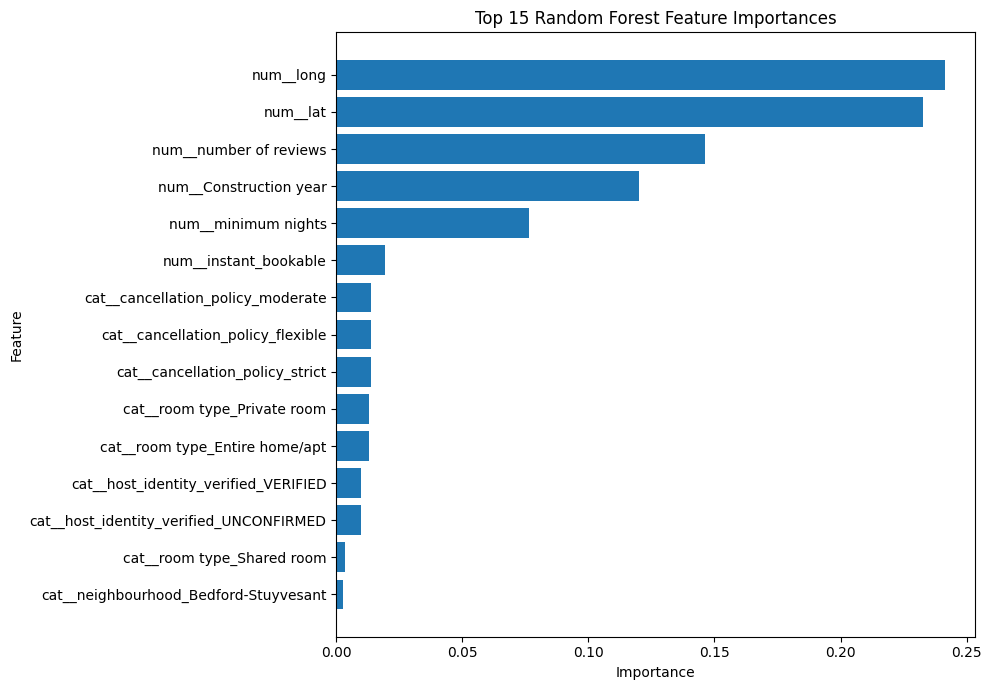

In [26]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

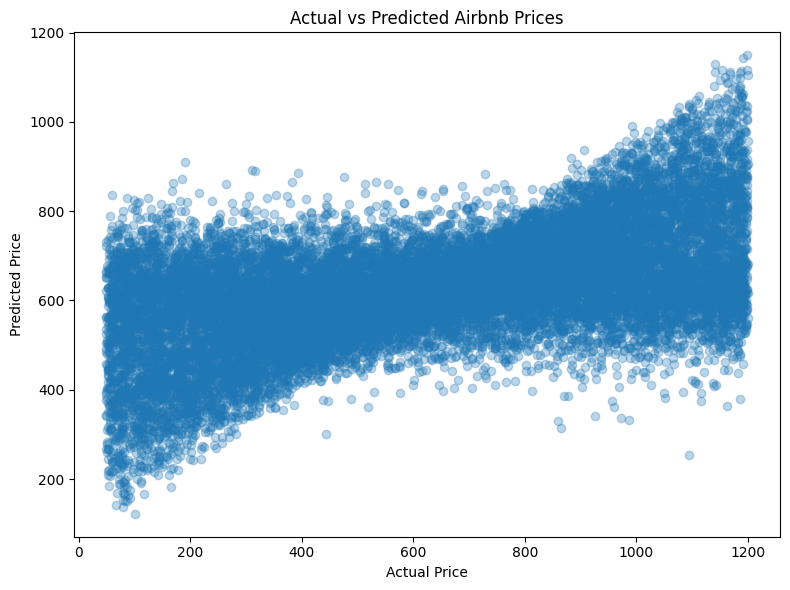

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Airbnb Prices')

plt.tight_layout()
plt.show()

In [28]:
# Generate predictions on training data
y_train_pred_rf = rf_model.predict(X_train_processed)

# Calculate training R²
train_r2_rf = r2_score(y_train, y_train_pred_rf)

print("Random Forest Overfitting Check")
print("--------------------------------")
print("Training R²:", round(train_r2_rf, 4))
print("Testing R² :", round(r2_rf, 4))

Random Forest Overfitting Check
--------------------------------
Training R²: 0.9002
Testing R² : 0.2862


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_processed, y_train)

print("Tuned Random Forest model trained successfully!")

Tuned Random Forest model trained successfully!


In [31]:
# Predictions using tuned model
y_pred_tuned = rf_tuned.predict(X_test_processed)

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Evaluation")
print("--------------------------------")
print("MAE :", round(mae_tuned, 2))
print("MSE :", round(mse_tuned, 2))
print("RMSE:", round(rmse_tuned, 2))
print("R²  :", round(r2_tuned, 4))

Tuned Random Forest Evaluation
--------------------------------
MAE : 282.76
MSE : 107074.67
RMSE: 327.22
R²  : 0.0272


In [32]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_tuned
    ],
    "MSE": [
        mse_linear,
        mse_rf,
        mse_tuned
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_tuned
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_tuned
    ]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,286.931180,110293.200467,332.104201,-0.002051
1,Random Forest,228.645318,78564.897072,280.294304,0.286211
2,Tuned Random Forest,282.758825,107074.668257,327.222659,0.027190


In [33]:
# Training predictions for tuned model
y_train_pred_tuned = rf_tuned.predict(X_train_processed)

# Training R²
train_r2_tuned = r2_score(y_train, y_train_pred_tuned)

print("Tuned Random Forest Overfitting Check")
print("--------------------------------")
print("Training R²:", round(train_r2_tuned, 4))
print("Testing R² :", round(r2_tuned, 4))

Tuned Random Forest Overfitting Check
--------------------------------
Training R²: 0.0856
Testing R² : 0.0272


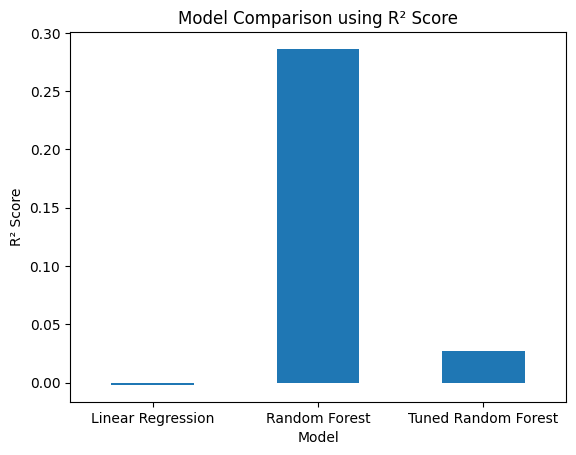

In [34]:
import matplotlib.pyplot as plt

comparison.set_index("Model")["R²"].plot(kind="bar")

plt.title("Model Comparison using R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()